# Crypt Shape Figures

This notebook contains the morphology-distribution analysis moved out of `plot_crypt_compositions.ipynb`. It uses the same datasets, graph preprocessing, timepoint cutoff, and pooled timepoint labels as `plot_marker_neighborhood.ipynb`.


## Imports


In [1]:
# If you edit paths or grouping, re-run this cell and everything below.
import os
import warnings
import glob
from functools import lru_cache

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from organograph.graph.io import load_cell_graph
from organograph.graph.access import graph_get

from organograph.crypts.analysis_markers import (
    bin_marker_positivity,
    get_marker_counts_per_patch,
    assign_coexpression_category,
)
from organograph.crypts.filters import filter_crypts_by_markers
from organograph.io_utils.segmentation_io import (
    load_graph_crypt_segmentation,
    load_mesh_crypt_segmentation,
)
from organograph.mesh.OrganoidMesh import OrganoidMesh
from organograph.mesh.hks import compute_hks
from organograph.plotting.colors import resolve_category_colors
from organograph.skeleton.build import (
    _low_pass_smoothed_mesh_for_detection,
    _select_hks_tips_from_axis,
)


## Configuration

Dataset and timepoint settings mirror `plot_marker_neighborhood.ipynb`. The original marker-aware crypt filter remains configurable below.


In [2]:
# Re-run from here if you change datasets, timepoints, or filtering.
PROJECT_ROOT = os.path.abspath(os.getcwd())
if os.path.basename(PROJECT_ROOT) in {"notebooks", "notebooks_dev", "legacy"}:
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
DATA_ROOT = os.path.join(PROJECT_ROOT, "..", "NicoleData")

NOTEBOOK_NAME = "plot_crypt_shapes"
EXPORT_DIR = os.path.join(PROJECT_ROOT, "exports", NOTEBOOK_NAME)
os.makedirs(EXPORT_DIR, exist_ok=True)


def export_figure(fig, filename):
    """Save a Matplotlib figure as a tightly cropped PDF in the notebook export folder."""
    safe_name = "".join(
        char if char.isalnum() or char in {"_", "-"} else "_"
        for char in str(filename)
    ).strip("_")
    path = os.path.join(EXPORT_DIR, f"{safe_name}.pdf")
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path


# Match plot_marker_neighborhood.ipynb.
DATASETS = ["20250929", "20251201"]
SEG_SUBDIR = "crypt_segmentations_graph"
GRAPH_SUBDIR = "graphs_preprocessed"
MIN_TIMEPOINT_NUMERIC = 2.5
EXCLUDE_TIMEPOINTS = {"day4"}

# Preserve the crypt selection used by the original morphology section.
USE_CRYPT_FILTER = True
CRYPT_FILTER_KW = dict(
    pos_marker_names=["LGR5", "Chroma", "Agr2", "Serotonin", "Lysozyme"],
    neg_marker_names=["AldoB"],
    pos_min=1,
    neg_min=2,
    roi_frac=0.75,
    require_all_pos=False,
)

COEX_MARKERS = {
    "LGR5": "LGR5",
    "Sero": "Serotonin",
    "Lyso": "Lysozyme",
}
MIN_POSITIVE = 1
POS_THRESHOLD = 1


def timepoint_to_float(tp):
    return float(str(tp).replace("day", "").replace("p", ".").replace("-more", ""))


def timepoint_label(tp):
    return f"day {timepoint_to_float(tp):g}"


## Load Crypt-Level Shape Table

Segmentation files are discovered for both datasets. Identical biological timepoints are pooled under one display label, including `day4p5-more` with `day4p5`.


In [3]:
from organograph.io_utils.cells_table import harmonize_markers

def discover_timepoints(seg_dir):
    if not os.path.isdir(seg_dir):
        return []
    tps = []
    for name in sorted(os.listdir(seg_dir)):
        p = os.path.join(seg_dir, name)
        if os.path.isdir(p) and glob.glob(os.path.join(p, "*.npz")):
            tps.append(name)
    return tps


def _seg_get(seg, *keys, default=None):
    for k in keys:
        if k in seg:
            return seg[k]
    return default


def _safe_array(x):
    if x is None:
        return None
    return np.asarray(x)


def _as_list_of_lists(x):
    if x is None:
        return []
    if isinstance(x, list):
        return [list(xx) for xx in x]
    if isinstance(x, np.ndarray) and x.dtype == object:
        return [list(xx) for xx in x.tolist()]
    return [list(xx) for xx in x]


def _infer_marker_names(G):
    """
    Read marker names from the graph itself.
    """
    for k in ["marker_names", "markers", "marker_cols"]:
        v = G.graph.get(k, None)
        if v is not None:
            return list(v)

    markers_bin = graph_get(G, "markers_bin")
    n_markers = markers_bin.shape[1]
    return [f"marker_{i}" for i in range(n_markers)]


def _infer_label_uid(G, fallback=None):
    return G.graph.get("label_uid", None) or fallback


@lru_cache(maxsize=None)
def load_graph_cached(graph_path):
    return load_cell_graph(graph_path)


def build_dataset_paths(data_spec, data_root):
    dataset = data_spec["dataset"]

    seg_subdir = data_spec.get("seg_subdir", "crypt_segmentations_graph")
    graph_subdir = data_spec.get("graph_subdir", "graphs_preprocessed")

    seg_dir = os.path.join(data_root, dataset, seg_subdir)
    graphs_dir = os.path.join(data_root, dataset, graph_subdir)

    return seg_dir, graphs_dir


def resolve_graph_path(seg, graphs_dir):
    """
    Prefer the graph path stored in the segmentation if it exists.
    Otherwise try to rebuild it relative to the dataset-specific graphs_dir.
    """
    graph_path = seg.get("graph_path", None)

    if graph_path is not None and os.path.exists(graph_path):
        return graph_path

    if graph_path is None:
        return None

    # fallback: use basename inside graphs_dir
    base = os.path.basename(graph_path)
    candidate = os.path.join(graphs_dir, base)
    if os.path.exists(candidate):
        return candidate

    return graph_path


def resolve_mesh_path(seg, dataset_root=None):
    mesh_path = seg.get("mesh_path", None)
    if mesh_path is None:
        return None
    return mesh_path


def iter_selected_seg_paths(data_specs, data_root, verbose=True):
    """
    Iterate through all requested segmentation files.
    Yields dicts with:
      dataset, timepoint, label, seg_path, seg_dir, graphs_dir
    """
    for ds in data_specs:
        seg_dir, graphs_dir = build_dataset_paths(ds, data_root)

        tps = ds.get("timepoints", None)
        if tps is None:
            tps = discover_timepoints(seg_dir)

        for tp in tps:
            tp_dir = os.path.join(seg_dir, tp)
            seg_paths = sorted(glob.glob(os.path.join(tp_dir, "*.npz")))

            if verbose and len(seg_paths) == 0:
                print(f"[warn] no segmentation files found in: {tp_dir}")

            for seg_path in seg_paths:
                yield {
                    "dataset": ds["dataset"],
                    "timepoint": tp,
                    "label": ds.get("label", f'{ds["dataset"]}:{tp}'),
                    "seg_path": seg_path,
                    "seg_dir": seg_dir,
                    "graphs_dir": graphs_dir,
                }
                

def infer_common_markers(data_specs, data_root, verbose=True):
    """
    Intersect marker names across all selected graphs.
    Returns common markers in the order they first appear.
    """
    marker_sets = []
    ordered_first = None

    for item in iter_selected_seg_paths(data_specs, data_root, verbose=verbose):
        seg_path = item["seg_path"]
        graphs_dir = item["graphs_dir"]

        try:
            seg = load_graph_crypt_segmentation(seg_path)
            graph_path = resolve_graph_path(seg, graphs_dir=graphs_dir)
            G = load_graph_cached(graph_path)
            marker_names = _infer_marker_names(G)
        except Exception as e:
            if verbose:
                print(f"[skip common-marker scan] {seg_path}: {e}")
            continue

        marker_set = set(marker_names)
        marker_sets.append(marker_set)

        if ordered_first is None:
            ordered_first = list(marker_names)

    if len(marker_sets) == 0:
        return []

    common = set.intersection(*marker_sets)
    if ordered_first is None:
        return sorted(common)

    return [m for m in ordered_first if m in common]


def make_graph_aware_crypt_filter(
    pos_marker_names=None,
    neg_marker_names=None,
    pos_min=2,
    neg_min=2,
    roi_frac=0.65,
    require_all_pos=True,
):
    pos_marker_names = [] if pos_marker_names is None else list(pos_marker_names)
    neg_marker_names = [] if neg_marker_names is None else list(neg_marker_names)

    def _crypt_filter(G, crypts_graph, seg, marker_names):
        name_to_idx = {m: i for i, m in enumerate(marker_names)}

        pos_markers = [name_to_idx[m] for m in pos_marker_names if m in name_to_idx]
        neg_markers = [name_to_idx[m] for m in neg_marker_names if m in name_to_idx]

        # If a requested positive marker is absent, require nothing from it.
        # If a requested negative marker is absent, also ignore it.
        return filter_crypts_by_markers(
            G,
            crypts_graph,
            pos_markers=pos_markers,
            neg_markers=neg_markers,
            pos_min=pos_min,
            neg_min=neg_min,
            roi_frac=roi_frac,
            dist_bottom=seg["d_crypts_graph"],
            require_all_pos=require_all_pos,
        )

    return _crypt_filter


def lighten_color(rgb_or_hex, amount=0.65):
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(rgb_or_hex))
    return tuple((1 - amount) * c + amount * np.ones(3))


def load_seg_cached(seg_path):
    return load_graph_crypt_segmentation(seg_path)


@lru_cache(maxsize=128)
def load_mesh_seg_cached(seg_path):
    return load_mesh_crypt_segmentation(seg_path)


def graph_crypt_to_mesh_index(graph_seg, graph_crypt_idx):
    """Map a retained graph-crypt index back to its mesh-segmentation crypt index."""
    mesh_to_graph = np.asarray(graph_seg.get("mesh_to_graph_index", []), dtype=np.int64)
    matches = np.flatnonzero(mesh_to_graph == int(graph_crypt_idx))
    if matches.size == 1:
        return int(matches[0])
    if matches.size > 1:
        raise ValueError(f"Multiple mesh crypts map to graph crypt {graph_crypt_idx}")
    return None


def std_bottom_gaussian_curvature(mesh_seg, mesh_crypt_idx, max_distance=0.50):
    """Compute the Gaussian-curvature standard deviation below max_distance."""
    if mesh_seg is None or mesh_crypt_idx is None:
        return np.nan

    curvature = np.asarray(mesh_seg.get("curvature_gauss", []), dtype=float)
    distances = np.asarray(mesh_seg.get("d_crypts", []), dtype=float)
    crypts_mesh = mesh_seg.get("crypts_mesh", [])
    if curvature.ndim != 1 or distances.ndim != 2:
        return np.nan
    if mesh_crypt_idx < 0 or mesh_crypt_idx >= len(crypts_mesh) or mesh_crypt_idx >= distances.shape[0]:
        return np.nan

    vertices = np.asarray(list(crypts_mesh[mesh_crypt_idx]), dtype=np.int64)
    vertices = vertices[(vertices >= 0) & (vertices < curvature.size) & (vertices < distances.shape[1])]
    if vertices.size == 0:
        return np.nan

    values = curvature[vertices]
    dvals = distances[mesh_crypt_idx, vertices]
    keep = np.isfinite(values) & np.isfinite(dvals) & (dvals < float(max_distance))
    return float(np.std(values[keep])) if np.any(keep) else np.nan


def get_roi_cells_for_crypt(crypt_cells, dist_bottom, crypt_number=None, roi_frac=None):
    """
    Restrict crypt cells to those with dist_bottom <= roi_frac.

    Supports:
      - dist_bottom shape (N_cells,)          : one global per-cell array
      - dist_bottom shape (K_crypts, N_cells) : one row per crypt

    Parameters
    ----------
    crypt_cells : list[int]
        Cell ids belonging to this crypt.
    dist_bottom : array-like
        Either shape (N_cells,) or (K_crypts, N_cells).
    crypt_number : int or None
        Required when dist_bottom has shape (K_crypts, N_cells).
        Should be the original crypt index in the segmentation.
    roi_frac : float or None
        If None, keep all crypt cells.
        Otherwise keep only cells with dist_bottom <= roi_frac.

    Returns
    -------
    roi_cells : np.ndarray of int
    """
    idx = np.asarray(list(crypt_cells), dtype=np.int64)

    if roi_frac is None:
        return idx

    db = np.asarray(dist_bottom, dtype=float)

    if db.ndim == 1:
        db_row = db

    elif db.ndim == 2:
        if crypt_number is None:
            raise ValueError(
                "crypt_number is required when dist_bottom has shape (K_crypts, N_cells)."
            )
        if crypt_number < 0 or crypt_number >= db.shape[0]:
            raise ValueError(
                f"crypt_number={crypt_number} out of range for dist_bottom with shape {db.shape}."
            )
        db_row = db[int(crypt_number)]

    else:
        raise ValueError(
            "dist_bottom must have shape (N_cells,) or (K_crypts, N_cells)."
        )

    if np.any(idx < 0) or np.any(idx >= len(db_row)):
        raise ValueError("crypt_cells contains indices out of range for dist_bottom.")

    dvals = db_row[idx]
    keep = np.isfinite(dvals) & (dvals <= float(roi_frac))
    return idx[keep]


def compute_crypt_shape_metrics(seg, crypt_idx, fullness_power=1.0):
    """
    Compute scalar shape metrics for one crypt from segmentation data.

    Metrics
    -------
    crypt_length : float
        L

    crypt_cmax : float
        max circumference inside crypt (d_discretized <= 1)

    crypt_slenderness : float
        L / C_max

    crypt_fullness : float
        Weighted mean normalized position of circumference:
            mu = (∫ d * C(d)^p dd) / (∫ C(d)^p dd)

    crypt_circ_pos_var : float
        Weighted variance of circumference position:
            var = (∫ (d-mu)^2 * C(d)^p dd) / (∫ C(d)^p dd)

    crypt_circ_pos_spread : float
        sqrt(var)

    crypt_circ_pos_spread_norm : float
        2 * sqrt(var), roughly scaled to [0, 1]
    """
    L_crypts = _safe_array(_seg_get(seg, "L_crypts", default=None))
    circumference_crypts = _safe_array(_seg_get(seg, "circumference_crypts", default=None))
    d_discretized = _safe_array(_seg_get(seg, "d_discretized", default=None))

    out = {
        "crypt_length": np.nan,
        "crypt_cmax": np.nan,
        "crypt_slenderness": np.nan,
        "crypt_fullness": np.nan,
        "crypt_circ_pos_var": np.nan,
        "crypt_circ_pos_spread": np.nan,
        "crypt_circ_pos_spread_norm": np.nan,
    }

    if L_crypts is None or circumference_crypts is None or d_discretized is None:
        return out

    if crypt_idx < 0 or crypt_idx >= len(L_crypts):
        return out

    try:
        L = float(L_crypts[crypt_idx])
        C = np.asarray(circumference_crypts[crypt_idx], dtype=float)
        d = np.asarray(d_discretized, dtype=float)
    except Exception:
        return out

    if C.ndim != 1 or d.ndim != 1 or len(C) != len(d):
        return out

    keep = np.isfinite(d) & np.isfinite(C) & (d <= 1.0)
    if not np.any(keep):
        return out

    d_roi = d[keep]
    C_roi = C[keep]

    order = np.argsort(d_roi)
    d_roi = d_roi[order]
    C_roi = C_roi[order]

    C_max = float(np.nanmax(C_roi)) if len(C_roi) > 0 else np.nan
    slenderness = float(L / C_max) if np.isfinite(L) and C_max > 0 else np.nan

    p = float(fullness_power)
    if p <= 0:
        raise ValueError("fullness_power must be > 0")

    W = C_roi ** p
    denom = np.trapezoid(W, d_roi)

    if denom > 0:
        mu = float(np.trapezoid(d_roi * W, d_roi) / denom)
        var = float(np.trapezoid(((d_roi - mu) ** 2) * W, d_roi) / denom)
        var = max(var, 0.0)
        spread = float(np.sqrt(var))
        spread_norm = float(2.0 * spread)
    else:
        mu = np.nan
        var = np.nan
        spread = np.nan
        spread_norm = np.nan

    return {
        "crypt_length": L,
        "crypt_cmax": C_max,
        "crypt_slenderness": slenderness,
        "crypt_fullness": mu,
        "crypt_circ_pos_var": var,
        "crypt_circ_pos_spread": spread,
        "crypt_circ_pos_spread_norm": spread_norm,
    }


In [4]:
def build_data_specs():
    specs = []
    for dataset in DATASETS:
        seg_dir = os.path.join(DATA_ROOT, dataset, SEG_SUBDIR)
        for timepoint in discover_timepoints(seg_dir):
            if timepoint in EXCLUDE_TIMEPOINTS:
                continue
            try:
                time_numeric = timepoint_to_float(timepoint)
            except ValueError:
                warnings.warn(f"Skipping unrecognized timepoint directory: {timepoint}")
                continue
            if MIN_TIMEPOINT_NUMERIC is not None and time_numeric < float(MIN_TIMEPOINT_NUMERIC):
                continue
            specs.append({
                "dataset": dataset,
                "seg_subdir": SEG_SUBDIR,
                "graph_subdir": GRAPH_SUBDIR,
                "timepoints": [timepoint],
                "label": timepoint_label(timepoint),
                "time_numeric": time_numeric,
            })
    return sorted(specs, key=lambda spec: (spec["time_numeric"], spec["dataset"], spec["timepoints"][0]))


DATA_SPECS = build_data_specs()
if not DATA_SPECS:
    raise FileNotFoundError(
        f"No segmentation files found under {DATA_ROOT} for {DATASETS} / {SEG_SUBDIR}"
    )

SAMPLE_ORDER = list(dict.fromkeys(spec["label"] for spec in DATA_SPECS))
pd.DataFrame(DATA_SPECS)[["dataset", "timepoints", "label", "seg_subdir", "graph_subdir"]]


,dataset,timepoints,label,seg_subdir,graph_subdir
0,20250929,[day3p5],day 3.5,crypt_segmentations_graph,graphs_preprocessed
1,20250929,[day4p5],day 4.5,crypt_segmentations_graph,graphs_preprocessed
2,20250929,[day4p5-more],day 4.5,crypt_segmentations_graph,graphs_preprocessed
3,20251201,[day4p5],day 4.5,crypt_segmentations_graph,graphs_preprocessed


In [5]:
def build_inspection_table_multi(
    data_specs,
    data_root,
    verbose=True,
    min_positive=1,
    pos_threshold=1,
    coex_markers=None,
    crypt_filter=None,
):
    rows_out = []

    coex_markers = {} if coex_markers is None else dict(coex_markers)

    for item in iter_selected_seg_paths(data_specs, data_root, verbose=verbose):
        dataset = item["dataset"]
        tp = item["timepoint"]
        label = item["label"]
        seg_path = item["seg_path"]
        graphs_dir = item["graphs_dir"]

        # load segmentation
        try:
            seg = load_graph_crypt_segmentation(seg_path)
        except Exception as e:
            if verbose:
                print(f"[skip] could not load segmentation {seg_path}: {e}")
            continue

        mesh_seg = None
        mesh_seg_path = seg.get("mesh_seg_path", None)
        if mesh_seg_path is not None:
            try:
                mesh_seg = load_mesh_seg_cached(str(mesh_seg_path))
            except Exception as e:
                if verbose:
                    print(f"[warn] could not load mesh segmentation {mesh_seg_path}: {e}")

        # resolve graph path using dataset-specific graphs_dir
        graph_path = resolve_graph_path(seg, graphs_dir=graphs_dir)

        # load graph
        try:
            G = load_graph_cached(graph_path)
        except Exception as e:
            if verbose:
                print(f"[skip] could not load graph {graph_path}: {e}")
            continue

        marker_names = _infer_marker_names(G)
        name_to_idx = {m: i for i, m in enumerate(marker_names)}

        crypts_graph = _as_list_of_lists(
            _seg_get(seg, "crypts_graph", "crypts_ll", "graph_crypts_ll", default=[])
        )
        constrictions = _safe_array(_seg_get(seg, "crypt_constrictions", default=None))
        elongations = _safe_array(_seg_get(seg, "crypt_elongations", "crypt_elongationss", default=None))
        graph_patch_sizes = _safe_array(_seg_get(seg, "graph_patch_sizes", default=None))

        label_uid = _seg_get(seg, "label_uid", default=None)
        label_uid = _infer_label_uid(G, fallback=label_uid)

        n_crypts = len(crypts_graph)

        # run filter once
        if crypt_filter is None:
            keep_idx = np.arange(n_crypts, dtype=np.int64)
        else:
            keep = crypt_filter(G, crypts_graph, seg, marker_names)

            if isinstance(keep, np.ndarray) and keep.dtype == bool:
                if len(keep) != n_crypts:
                    raise ValueError(
                        f"crypt_filter returned boolean mask of length {len(keep)}, "
                        f"expected {n_crypts}"
                    )
                keep_idx = np.flatnonzero(keep)
            else:
                keep_idx = np.asarray(keep, dtype=np.int64)

        if keep_idx.ndim != 1:
            raise ValueError("keep_idx must be a 1D array of crypt indices")
        if len(keep_idx) > 0:
            if keep_idx.min() < 0 or keep_idx.max() >= n_crypts:
                raise ValueError("crypt_filter returned out-of-range crypt indices")

        crypts_graph_f = [crypts_graph[j] for j in keep_idx]
        constrictions_f = constrictions[keep_idx] if constrictions is not None else None
        elongations_f = elongations[keep_idx] if elongations is not None else None
        graph_patch_sizes_f = graph_patch_sizes[keep_idx] if graph_patch_sizes is not None else None
        orig_crypt_numbers_f = keep_idx

        # coexpression indices if present in this graph
        i_LGR5 = name_to_idx.get(coex_markers.get("LGR5", ""), None)
        i_Sero = name_to_idx.get(coex_markers.get("Sero", ""), None)
        i_Lyso = name_to_idx.get(coex_markers.get("Lyso", ""), None)

        for local_idx, crypt_cells in enumerate(crypts_graph_f):
            crypt_cells = list(crypt_cells)
            if len(crypt_cells) == 0:
                continue

            orig_j = int(orig_crypt_numbers_f[local_idx])

            shape_metrics = compute_crypt_shape_metrics(seg, orig_j)
            mesh_crypt_idx = graph_crypt_to_mesh_index(seg, orig_j)
            curvature_std_bottom_50 = std_bottom_gaussian_curvature(
                mesh_seg,
                mesh_crypt_idx,
                max_distance=0.50,
            )

            num_pos_cells, num_cells = get_marker_counts_per_patch(G, crypt_cells)
            num_pos_cells = np.asarray(num_pos_cells, dtype=np.int64)

            if num_pos_cells.shape[0] != len(marker_names):
                raise ValueError(
                    f"Marker count mismatch for {seg_path}: "
                    f"counts have length {num_pos_cells.shape[0]}, "
                    f"marker_names has length {len(marker_names)}"
                )

            has_marker = (num_pos_cells >= min_positive).astype(np.int64)

            if None not in (i_LGR5, i_Sero, i_Lyso):
                coexpression_cat = assign_coexpression_category(
                    G,
                    crypt_cells,
                    i_LGR5,
                    i_Sero,
                    i_Lyso,
                    pos_threshold=pos_threshold,
                )
            else:
                coexpression_cat = np.nan

            constr = (
                float(constrictions_f[local_idx])
                if constrictions_f is not None and local_idx < len(constrictions_f)
                else np.nan
            )

            row = {
                "dataset": dataset,
                "timepoint": tp,
                "sample_label": label,
                "label_uid": label_uid,
                "crypt_number": orig_j,
                "crypt_number_filtered": local_idx,
                "graph_path": graph_path,
                "mesh_path": seg.get("mesh_path", None),
                "seg_path": seg_path if os.path.exists(seg_path) else None,
                "has_seg": bool(os.path.exists(seg_path)),
                "num_cells": int(num_cells),
                "constriction": constr,
                "elongation": (
                    float(elongations_f[local_idx])
                    if elongations_f is not None and local_idx < len(elongations_f)
                    else np.nan
                ),
                "graph_patch_size": (
                    int(graph_patch_sizes_f[local_idx])
                    if graph_patch_sizes_f is not None and local_idx < len(graph_patch_sizes_f)
                    else int(num_cells)
                ),
                "coexpression_cat": coexpression_cat,
                "is_budded": (constr > 0) if not np.isnan(constr) else np.nan,
                "crypt_cells": crypt_cells,
                "graph_marker_names": tuple(marker_names),
                "crypt_length": shape_metrics["crypt_length"],
                "crypt_cmax": shape_metrics["crypt_cmax"],
                "crypt_slenderness": shape_metrics["crypt_slenderness"],
                "crypt_fullness": shape_metrics["crypt_fullness"],
                "crypt_circ_pos_var": shape_metrics["crypt_circ_pos_var"],
                "crypt_circ_pos_spread": shape_metrics["crypt_circ_pos_spread"],
                "crypt_circ_pos_spread_norm": shape_metrics["crypt_circ_pos_spread_norm"],
                "std_curvature_gauss_bottom_50": curvature_std_bottom_50,
            }

            for k, mk in enumerate(marker_names):
                row[f"{mk}_n_pos"] = int(num_pos_cells[k])
                row[f"{mk}_frac_pos"] = float(num_pos_cells[k] / num_cells) if num_cells > 0 else np.nan
                row[f"{mk}_has"] = int(has_marker[k])

            rows_out.append(row)

    df = pd.DataFrame(rows_out)

    if len(df) == 0:
        return df

    has_cols = [c for c in df.columns if c.endswith("_has")]
    if len(has_cols) > 0:
        df["n_markers_present"] = df[has_cols].fillna(0).sum(axis=1)

    return df


In [6]:
crypt_filter = None
if USE_CRYPT_FILTER:
    crypt_filter = make_graph_aware_crypt_filter(**CRYPT_FILTER_KW)

inspection_df = build_inspection_table_multi(
    data_specs=DATA_SPECS,
    data_root=DATA_ROOT,
    verbose=True,
    min_positive=MIN_POSITIVE,
    pos_threshold=POS_THRESHOLD,
    coex_markers=COEX_MARKERS,
    crypt_filter=crypt_filter,
)

if inspection_df.empty:
    raise ValueError("No crypts were loaded for the configured datasets and timepoints.")

display(
    inspection_df.groupby(["sample_label", "dataset", "timepoint"])
    .size()
    .rename("n_crypts")
    .reset_index()
)
print("Pooled timepoint order:", SAMPLE_ORDER)
print(f"Total crypts: {len(inspection_df)}")


,sample_label,dataset,timepoint,n_crypts
0,day 3.5,20250929,day3p5,189
1,day 4.5,20250929,day4p5,117
2,day 4.5,20250929,day4p5-more,229
3,day 4.5,20251201,day4p5,313


Pooled timepoint order: ['day 3.5', 'day 4.5']
Total crypts: 848


## Shape and Curvature Distributions

`day4` is excluded. `day4p5` and `day4p5-more` are pooled as `day 4.5`. Distributions are shown for four mutually exclusive categories defined by LGR5 status and whether the crypt contains any Lysozyme-, Serotonin-, or Chroma-positive cells. Gaussian-curvature variation is calculated as the standard deviation across mesh vertices in the bottom 50% of each crypt (`d < 0.50`). Size-related and shape-related quantities are exported as separate figures.


,timepoint,category,n_crypts
0,day 3.5,"LGR5+; no Lysozyme, Serotonin, or Chroma",19
1,day 3.5,"LGR5-; no Lysozyme, Serotonin, or Chroma",24
2,day 3.5,"LGR5+; Lysozyme+, Serotonin+, or Chroma+",95
3,day 3.5,"LGR5-; Lysozyme+, Serotonin+, or Chroma+",51
4,day 4.5,"LGR5+; no Lysozyme, Serotonin, or Chroma",77
5,day 4.5,"LGR5-; no Lysozyme, Serotonin, or Chroma",32
6,day 4.5,"LGR5+; Lysozyme+, Serotonin+, or Chroma+",464
7,day 4.5,"LGR5-; Lysozyme+, Serotonin+, or Chroma+",86


Saved figure: /home/fmoller/Projects/LearningOrganoids/OrganoGraph/exports/plot_crypt_shapes/crypt_size_distributions_by_marker_category.pdf


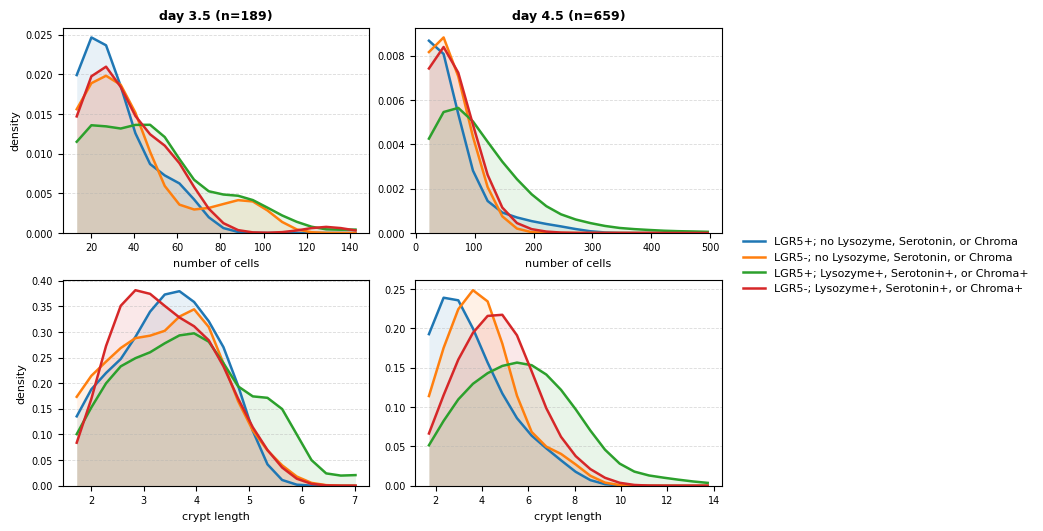

Saved figure: /home/fmoller/Projects/LearningOrganoids/OrganoGraph/exports/plot_crypt_shapes/crypt_shape_and_curvature_variation_by_marker_category.pdf


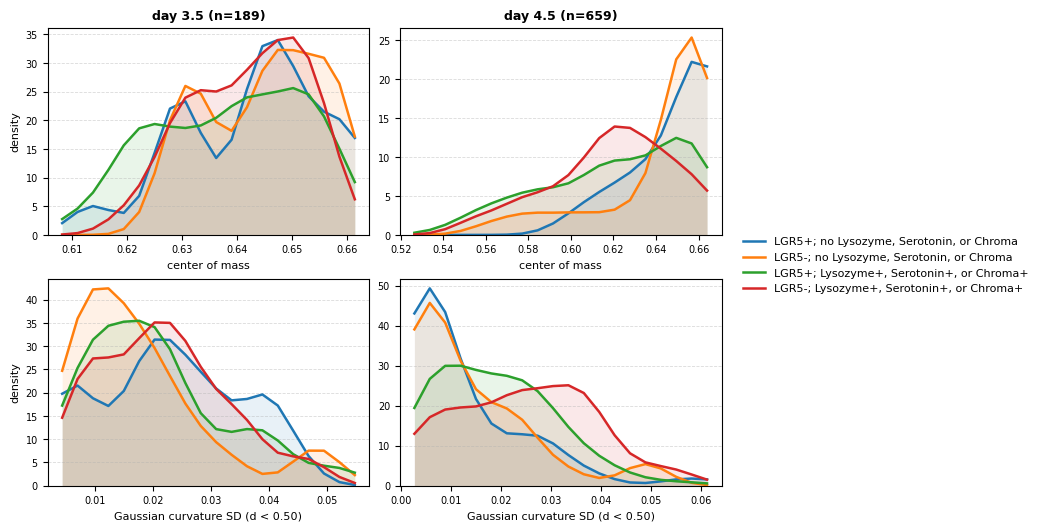

In [7]:
def gaussian_smooth_1d(y, sigma_bins=1.5):
    """Smooth a one-dimensional histogram with a Gaussian kernel in bin units."""
    y = np.asarray(y, dtype=float)
    if sigma_bins is None or sigma_bins <= 0:
        return y.copy()

    radius = int(np.ceil(4 * sigma_bins))
    x = np.arange(-radius, radius + 1, dtype=float)
    kernel = np.exp(-0.5 * (x / sigma_bins) ** 2)
    kernel /= kernel.sum()
    return np.convolve(y, kernel, mode="same")


def combine_shape_timepoints(inspection_df, out_col="shape_timepoint"):
    """Pool equivalent saved timepoint labels while leaving other timepoints unchanged."""
    df = inspection_df.copy()
    time_numeric = df["timepoint"].map(timepoint_to_float).astype(float)
    df[out_col] = df["sample_label"].astype(str)
    late_mask = np.isclose(time_numeric, 4.5)
    df.loc[late_mask, out_col] = "day 4.5"

    order_table = pd.DataFrame({
        out_col: df[out_col],
        "time_numeric": time_numeric,
    })
    timepoint_order = (
        order_table.groupby(out_col, sort=False)["time_numeric"]
        .min()
        .sort_values()
        .index.tolist()
    )
    return df, timepoint_order


def crypt_shape_category_masks(df):
    """Return four mutually exclusive marker-category masks."""
    required = ["LGR5_n_pos", "Lysozyme_n_pos", "Serotonin_n_pos", "Chroma_n_pos"]
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise KeyError(f"Missing marker-count columns required for shape categories: {missing}")

    lgr5_positive = pd.to_numeric(df["LGR5_n_pos"], errors="coerce").fillna(0).to_numpy() >= 1
    lysozyme_positive = pd.to_numeric(df["Lysozyme_n_pos"], errors="coerce").fillna(0).to_numpy() >= 1
    serotonin_positive = pd.to_numeric(df["Serotonin_n_pos"], errors="coerce").fillna(0).to_numpy() >= 1
    chroma_positive = pd.to_numeric(df["Chroma_n_pos"], errors="coerce").fillna(0).to_numpy() >= 1
    lineage_positive = lysozyme_positive | serotonin_positive | chroma_positive
    lineage_negative = ~lineage_positive

    return {
        "LGR5+; no Lysozyme, Serotonin, or Chroma": lgr5_positive & lineage_negative,
        "LGR5-; no Lysozyme, Serotonin, or Chroma": (~lgr5_positive) & lineage_negative,
        "LGR5+; Lysozyme+, Serotonin+, or Chroma+": lgr5_positive & lineage_positive,
        "LGR5-; Lysozyme+, Serotonin+, or Chroma+": (~lgr5_positive) & lineage_positive,
    }


CATEGORY_COLORS = {
    "LGR5+; no Lysozyme, Serotonin, or Chroma": "#1f77b4",
    "LGR5-; no Lysozyme, Serotonin, or Chroma": "#ff7f0e",
    "LGR5+; Lysozyme+, Serotonin+, or Chroma+": "#2ca02c",
    "LGR5-; Lysozyme+, Serotonin+, or Chroma+": "#d62728",
}


def summarize_shape_category_counts(df, timepoint_col, timepoint_order):
    rows = []
    for timepoint in timepoint_order:
        sub = df[df[timepoint_col] == timepoint]
        for category, mask in crypt_shape_category_masks(sub).items():
            rows.append({
                "timepoint": timepoint,
                "category": category,
                "n_crypts": int(np.count_nonzero(mask)),
            })
    return pd.DataFrame(rows)


def plot_shape_distributions_by_category(
    inspection_df,
    *,
    value_cols,
    value_labels=None,
    timepoint_col="shape_timepoint",
    timepoint_order=None,
    bins=20,
    density=True,
    smoothing=True,
    smoothing_sigma_bins=1.5,
    figsize_per_panel=(3.6, 2.6),
    line_width=1.8,
    fill_alpha=0.10,
    export_filename="crypt_shape_distributions",
):
    """Plot crypt-shape distributions for the requested marker-defined categories."""
    df = inspection_df.copy()
    value_cols = [value_cols] if isinstance(value_cols, str) else list(value_cols)
    value_labels = list(value_cols) if value_labels is None else list(value_labels)
    if len(value_cols) != len(value_labels):
        raise ValueError("value_cols and value_labels must have the same length")

    required = [timepoint_col, *value_cols]
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise KeyError(f"Missing required shape columns: {missing}")
    if timepoint_order is None:
        timepoint_order = list(pd.unique(df[timepoint_col]))

    n_rows = len(value_cols)
    n_cols = len(timepoint_order)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        squeeze=False,
        constrained_layout=True,
        sharey=False,
    )

    for row, (value_col, value_label) in enumerate(zip(value_cols, value_labels)):
        for col, timepoint in enumerate(timepoint_order):
            ax = axes[row, col]
            sub = df[df[timepoint_col] == timepoint].copy()
            all_values = pd.to_numeric(sub[value_col], errors="coerce").to_numpy(dtype=float)
            all_values = all_values[np.isfinite(all_values)]
            if all_values.size == 0:
                ax.axis("off")
                continue

            bin_edges = np.histogram_bin_edges(all_values, bins=bins)
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            bin_widths = np.diff(bin_edges)

            for category, mask in crypt_shape_category_masks(sub).items():
                values = pd.to_numeric(sub.loc[mask, value_col], errors="coerce").to_numpy(dtype=float)
                values = values[np.isfinite(values)]
                if values.size == 0:
                    continue

                hist, _ = np.histogram(values, bins=bin_edges)
                if hist.sum() == 0:
                    continue
                if density:
                    y = hist / (hist.sum() * bin_widths)
                else:
                    y = hist / hist.sum()
                if smoothing:
                    y = gaussian_smooth_1d(y, sigma_bins=smoothing_sigma_bins)

                color = CATEGORY_COLORS[category]
                ax.plot(
                    bin_centers,
                    y,
                    color=color,
                    linewidth=line_width,
                    label=category,
                )
                ax.fill_between(bin_centers, 0, y, color=color, alpha=fill_alpha, linewidth=0)

            if row == 0:
                ax.set_title(f"{timepoint} (n={len(sub)})", fontsize=9, fontweight="bold")
            ax.set_xlabel(value_label, fontsize=8)
            if col == 0:
                ax.set_ylabel("density" if density else "fraction of crypts", fontsize=8)
            ax.tick_params(labelsize=7)
            ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.45)
            ax.set_ylim(bottom=0)
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            frameon=False,
            ncol=1,
            loc="center left",
            bbox_to_anchor=(1.01, 0.5),
            fontsize=8,
        )

    export_figure(fig, export_filename)
    plt.show()
    return fig, axes


shape_df, SHAPE_TIMEPOINT_ORDER = combine_shape_timepoints(inspection_df)
shape_category_counts = summarize_shape_category_counts(
    shape_df,
    timepoint_col="shape_timepoint",
    timepoint_order=SHAPE_TIMEPOINT_ORDER,
)
display(shape_category_counts)

fig_size, axes_size = plot_shape_distributions_by_category(
    shape_df,
    value_cols=["num_cells", "crypt_length"],
    value_labels=["number of cells", "crypt length"],
    timepoint_col="shape_timepoint",
    timepoint_order=SHAPE_TIMEPOINT_ORDER,
    bins=20,
    density=True,
    smoothing=True,
    smoothing_sigma_bins=1.5,
    export_filename="crypt_size_distributions_by_marker_category",
)

fig_shape, axes_shape = plot_shape_distributions_by_category(
    shape_df,
    value_cols=["crypt_fullness", "std_curvature_gauss_bottom_50"],
    value_labels=["center of mass", "Gaussian curvature SD (d < 0.50)"],
    timepoint_col="shape_timepoint",
    timepoint_order=SHAPE_TIMEPOINT_ORDER,
    bins=20,
    density=True,
    smoothing=True,
    smoothing_sigma_bins=1.5,
    export_filename="crypt_shape_and_curvature_variation_by_marker_category",
)
